# 1. Understanding Data



# 2. Load and Inspect

In [ ]:
# ─── Standard Libraries ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ─── Visualization ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ─── Scikit-learn: Datasets ───────────────────────────────────────────────────
from sklearn.datasets import load_iris

# ─── Scikit-learn: Clustering ─────────────────────────────────────────────────
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN

# ─── Scikit-learn: Dimensionality Reduction ───────────────────────────────────
from sklearn.decomposition import PCA

# ─── Scikit-learn: Preprocessing ──────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler

# ─── Scipy for Dendrogram ─────────────────────────────────────────────────────
from scipy.cluster.hierarchy import dendrogram, linkage

# ─── Global Plot Style ────────────────────────────────────────────────────────
sns.set_style('darkgrid')
sns.set_palette('tab10')
RANDOM_STATE = 42

In [ ]:
df = pd.read_csv("/content/sample_data/Wholesale customers data.csv")
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185


In [ ]:
df.shape

(440, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Channel           440 non-null    int64
 1   Region            440 non-null    int64
 2   Fresh             440 non-null    int64
 3   Milk              440 non-null    int64
 4   Grocery           440 non-null    int64
 5   Frozen            440 non-null    int64
 6   Detergents_Paper  440 non-null    int64
 7   Delicassen        440 non-null    int64
dtypes: int64(8)
memory usage: 27.6 KB


In [ ]:
df.describe()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
count,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000,440.000000
mean,1.322727,2.543182,12000.297727,5796.265909,7951.277273,3071.931818,2881.493182,1524.870455
std,0.468052,0.774272,12647.328865,7380.377175,9503.162829,4854.673333,4767.854448,2820.105937
min,1.000000,1.000000,3.000000,55.000000,3.000000,25.000000,3.000000,3.000000
25%,1.000000,2.000000,3127.750000,1533.000000,2153.000000,742.250000,256.750000,408.250000
50%,1.000000,3.000000,8504.000000,3627.000000,4755.500000,1526.000000,816.500000,965.500000
75%,2.000000,3.000000,16933.750000,7190.250000,10655.750000,3554.250000,3922.000000,1820.250000
max,2.000000,3.000000,112151.000000,73498.000000,92780.000000,60869.000000,40827.000000,47943.000000


In [ ]:
df.isnull().sum()

,0
Channel,0
Region,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicassen,0


In [ ]:
df.dropna()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,2,3,12669,9656,7561,214,2674,1338
1,2,3,7057,9810,9568,1762,3293,1776
2,2,3,6353,8808,7684,2405,3516,7844
3,1,3,13265,1196,4221,6404,507,1788
4,2,3,22615,5410,7198,3915,1777,5185
...,...,...,...,...,...,...,...,...
435,1,3,29703,12051,16027,13135,182,2204
436,1,3,39228,1431,764,4510,93,2346
437,2,3,14531,15488,30243,437,14841,1867
438,1,3,10290,1981,2232,1038,168,2125


**Checkk**

In [ ]:
df.isnull().sum()

,0
Channel,0
Region,0
Fresh,0
Milk,0
Grocery,0
Frozen,0
Detergents_Paper,0
Delicassen,0


**No Change as there is no NULL Values**

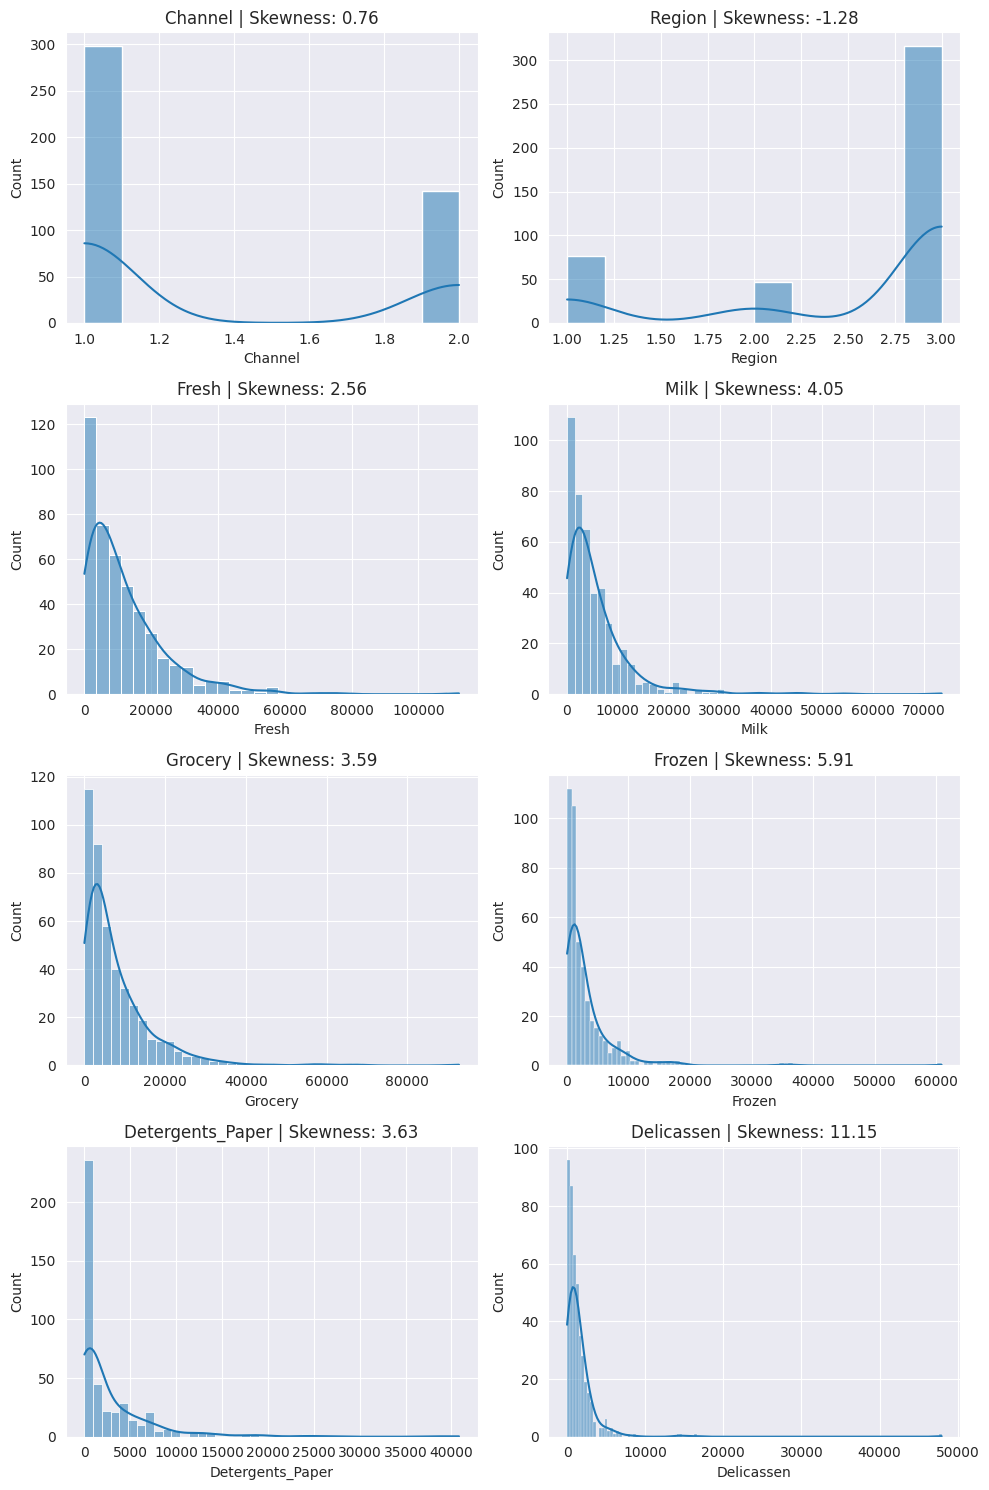

In [ ]:
import seaborn as sns

fig, axes = plt.subplots(nrows= 4, ncols= 2, figsize=(10, 15))
axes = axes.flatten()

for i, col in enumerate(df.columns):
  skew = df[col].skew().round(2)
  sns.histplot(df[col], ax=axes[i], kde=True)
  axes[i].set_title(f"{col} | Skewness: {skew}")

plt.tight_layout()
plt.show()

In [ ]:
df.skew().round(2)
print("\nHighly skewed columns (|skew| > 1):")


Highly skewed columns (|skew| > 1):


In [ ]:
print("\nHighly skewed columns (|skew| > 1):")
df.columns[df.skew().abs() > 1].tolist()


Highly skewed columns (|skew| > 1):


['Region',
 'Fresh',
 'Milk',
 'Grocery',
 'Frozen',
 'Detergents_Paper',
 'Delicassen']

# 3. Outliers Detection and Handling

In [ ]:
df_clean = df.drop(columns=["Channel", "Region"], axis= 1)
df_clean.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,12669,9656,7561,214,2674,1338
1,7057,9810,9568,1762,3293,1776
2,6353,8808,7684,2405,3516,7844
3,13265,1196,4221,6404,507,1788
4,22615,5410,7198,3915,1777,5185


**Removed Categorial Columns**

In [ ]:
Q1 = df_clean.quantile(0.25)
Q3 = df_clean.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - (1.5 * IQR)
upper_bound = Q3 + (1.5 * IQR)
outliers = (df_clean < lower_bound) | (df_clean > upper_bound)

outliers.sum()

,0
Fresh,20
Milk,28
Grocery,24
Frozen,43
Detergents_Paper,30
Delicassen,27


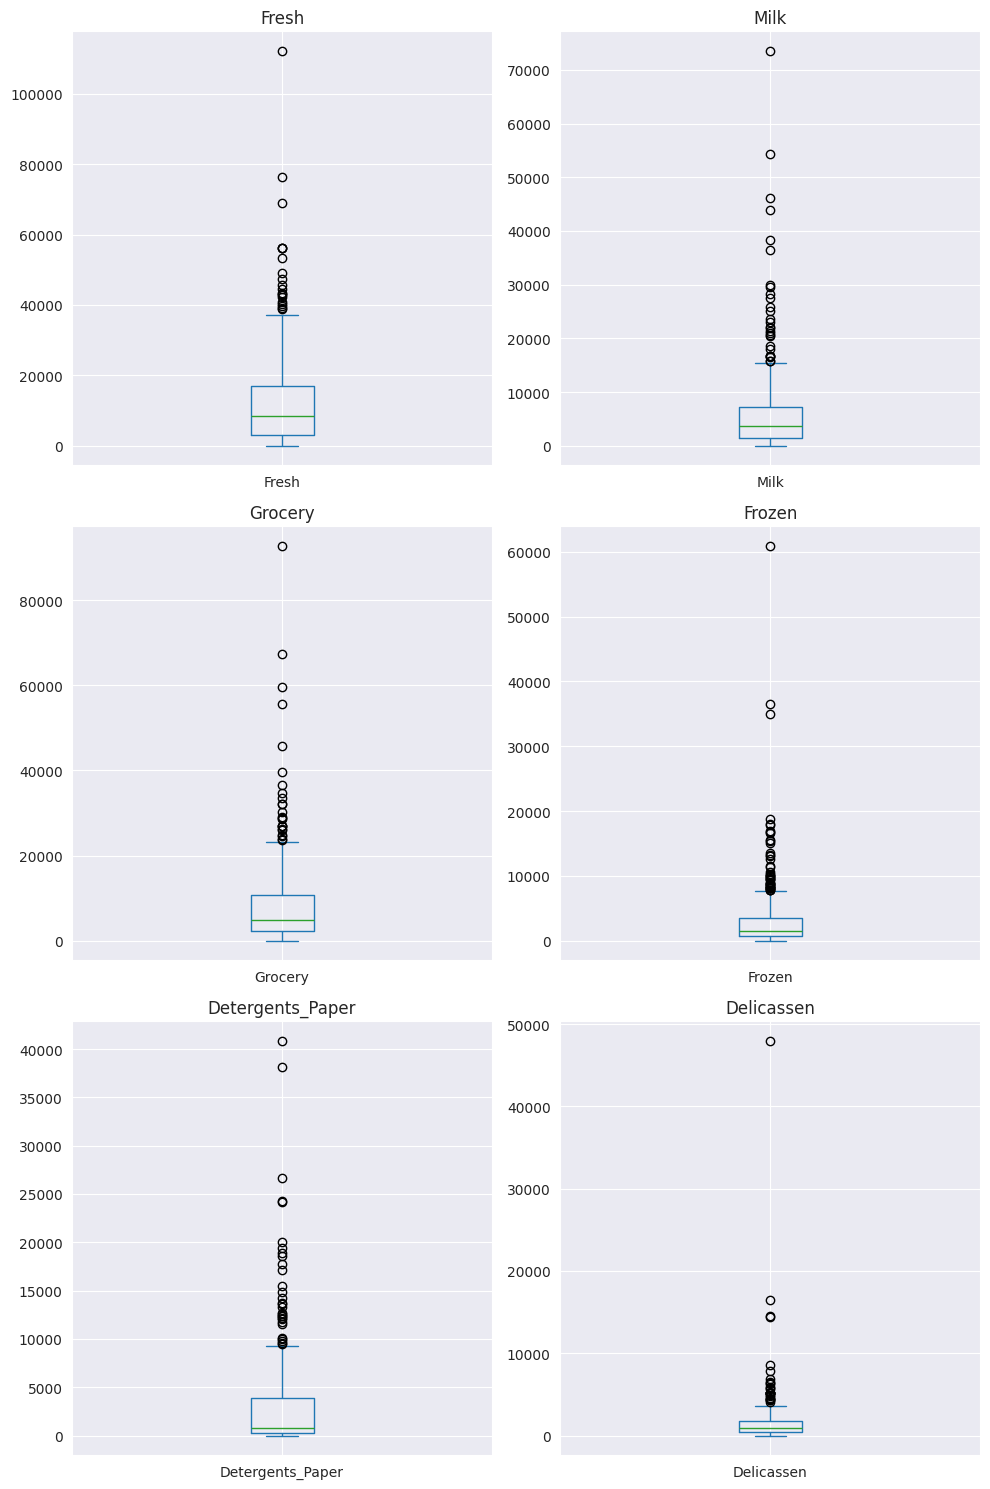

In [ ]:
fig, axes = plt.subplots(nrows= 3, ncols= 2, figsize=(10, 15))
axes = axes.flatten()

for i, col in enumerate(df_clean.columns):
  df_clean[col].plot(kind= 'box', ax= axes[i], title= col)

plt.tight_layout()
plt.show()

In [ ]:
outliers = [
    'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'
          ]
for col in outliers:
  Q1 = df_clean[col].quantile(0.25)
  Q3 = df_clean[col].quantile(0.75)
  IQR = Q3 - Q1
  lower_bound = Q1 - (1.5 * IQR)
  upper_bound = Q3 + (1.5 * IQR)
  df_clean[col] = df_clean[col].clip(lower= lower_bound, upper= upper_bound)

**CHeck NOW**

In [ ]:
for col in df_clean:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n = ((df_clean[col] < lower) | (df_clean[col] > upper)).sum()
    print(f"{col}: {n}")

Fresh: 0
Milk: 0
Grocery: 0
Frozen: 0
Detergents_Paper: 0
Delicassen: 0


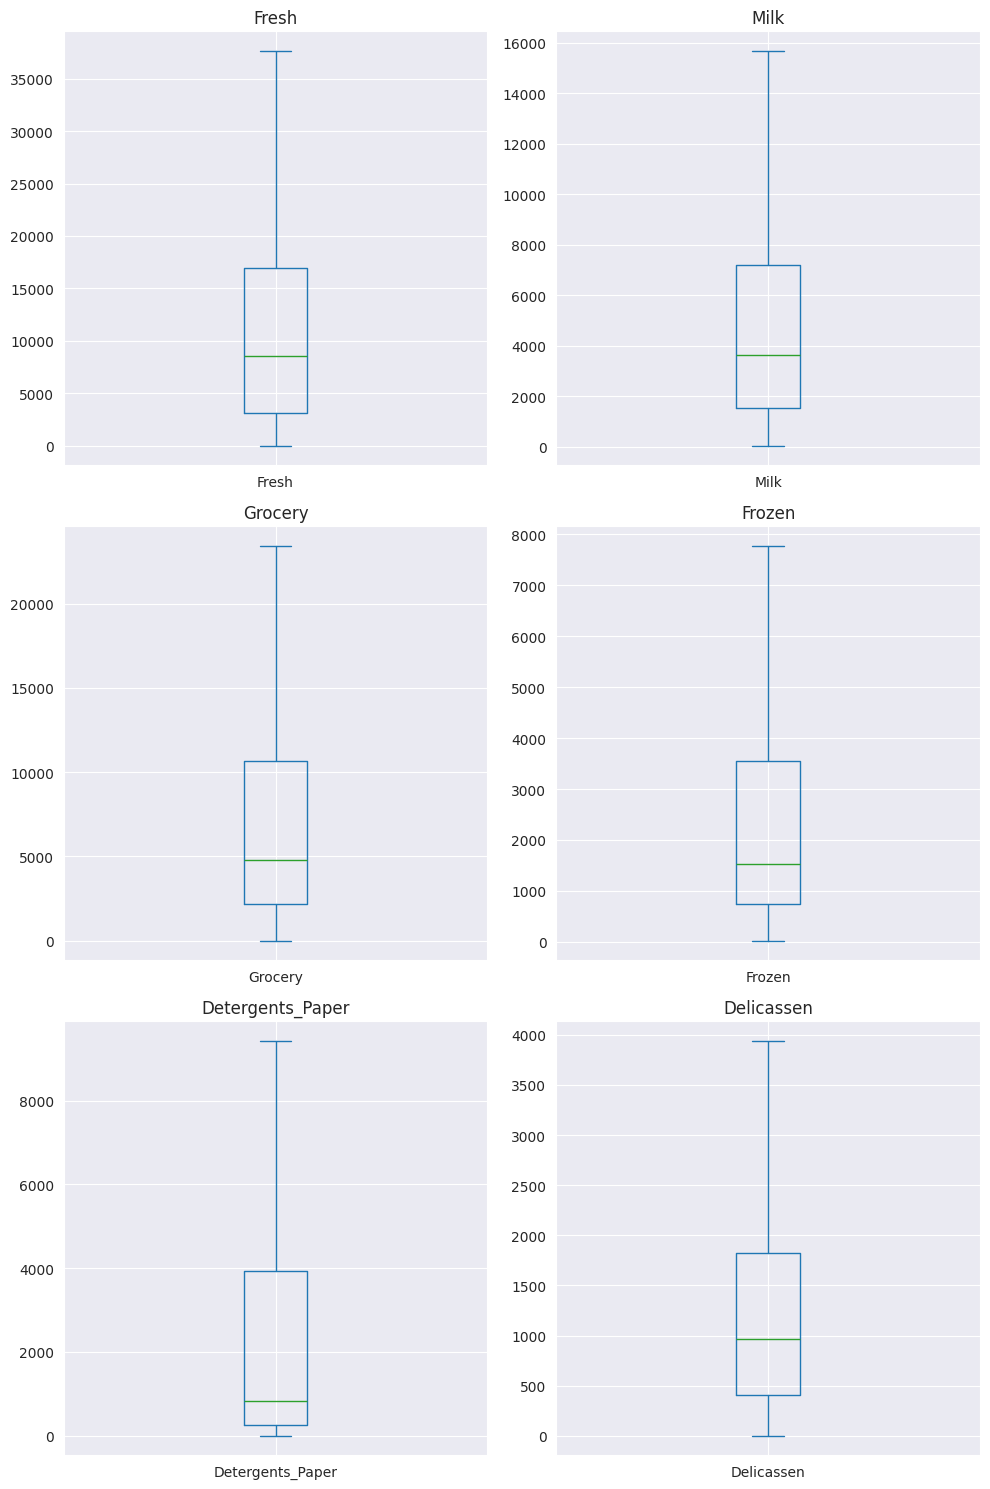

In [ ]:
fig, axes = plt.subplots(nrows= 3, ncols= 2, figsize=(10, 15))
axes = axes.flatten()

for i, col in enumerate(df_clean.columns):
  df_clean[col].plot(kind= 'box', ax= axes[i], title= col)

plt.tight_layout()
plt.show()

**Outliers were handled using IQR-based clipping to reduce their impact while preserving the overall distribution of the data.**

# 4. Correlation Analysis

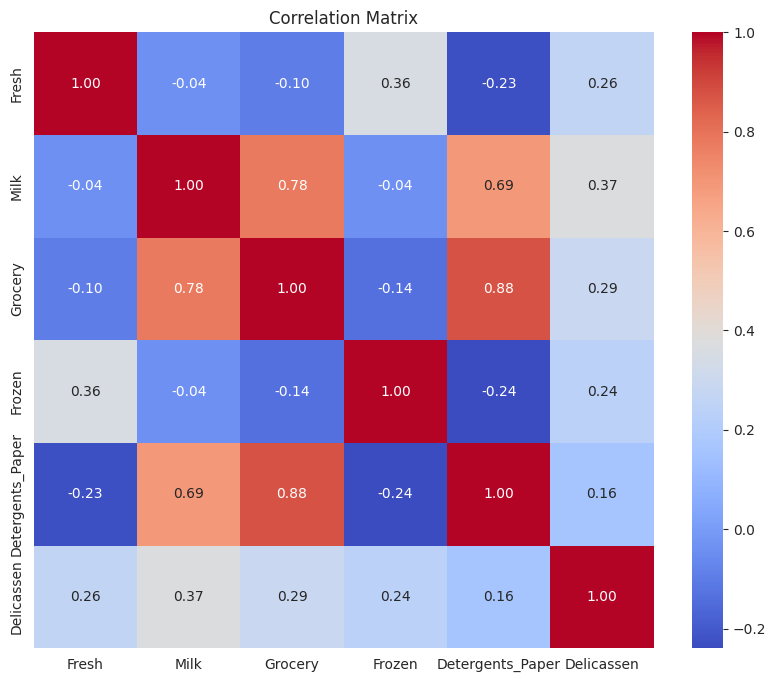

In [ ]:
plt.figure(figsize=(10, 8))
sns.heatmap(df_clean.corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

**Milk, Grocery and Detergents_Paper show strong postive correlation, indicating that the customer who spend more on of these categories spends more on the otheres as well. In contrast the other features are relatively independent**

# 4. Handling Skewness with Log Transformation

**The data distributions observed during EDA showed significant skewness across most features. Since clustering algorithms are sensitive to the scale and distribution of data, a log transformation was applied to reduce skewness and stabilize variance.**

In [ ]:
df_log = np.log1p(df_clean)
df_log.head()

,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen
0,9.446992,9.175438,8.930891,5.370638,7.891705,7.199678
1,8.861917,9.191259,9.166284,7.474772,8.099858,7.482682
2,8.756840,9.083529,8.947026,7.785721,8.165364,8.278746
3,9.492960,7.087574,8.348064,8.764834,6.230481,7.489412
4,10.026413,8.596189,8.881697,8.272826,7.483244,8.278746


In [ ]:
df_log.skew().round(2)

,0
Fresh,-1.66
Milk,-0.50
Grocery,-0.89
Frozen,-0.64
Detergents_Paper,-0.37
Delicassen,-1.41


# 4.1 Feature Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_log)

# 4.2 Applying PCA

In [ ]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

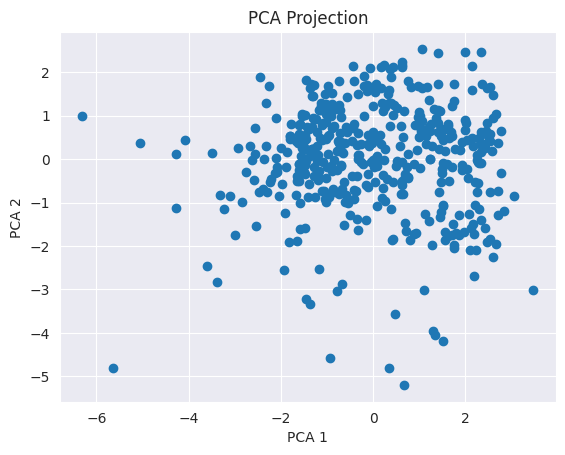

In [ ]:
plt.scatter(pca_data[:, 0], pca_data[:, 1])
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("PCA Projection")
plt.show()

# 5. K-Means Clustering

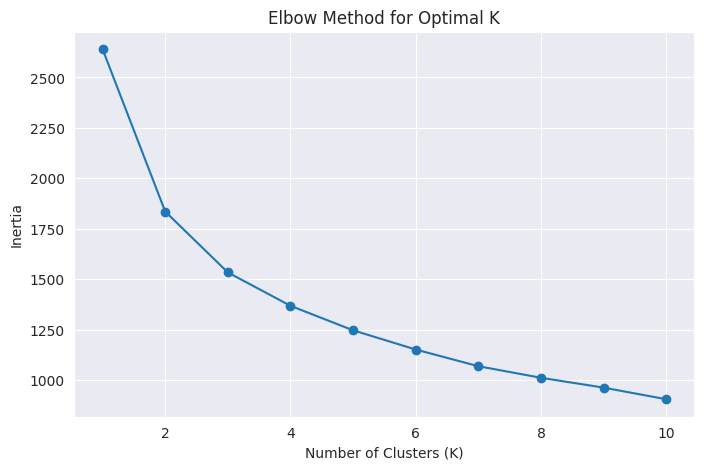

In [ ]:
# Finding Optimal Number of Clusters (Elbow Method)
inertia_values = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(scaled_data)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K_range, inertia_values, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

In [ ]:
# Fit Final K-Means Model
optimal_k = 5

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_labels = kmeans.fit_predict(scaled_data)

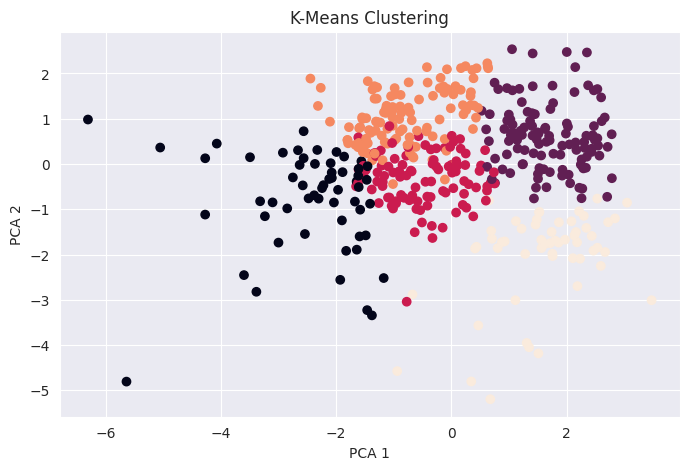

In [ ]:
plt.figure(figsize=(8,5))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=kmeans_labels)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("K-Means Clustering")
plt.show()

**K-Means clustering grouped the customers into distinct segments based on their purchasing behavior. The clusters appear relatively well-separated in the PCA projection, indicating meaningful segmentation.**

# 6. Hierarchical Clustering

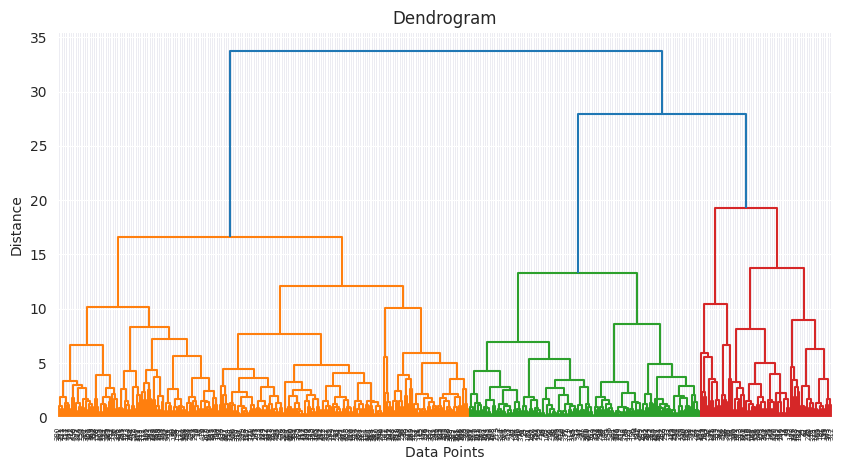

In [ ]:
# Create Linkage Matrix
linked = linkage(scaled_data, method='ward')

# Plot Dendrogram
plt.figure(figsize=(10,5))
dendrogram(linked)
plt.title("Dendrogram")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()

Based on the dendrogram, the number of clusters is selected as **3**.

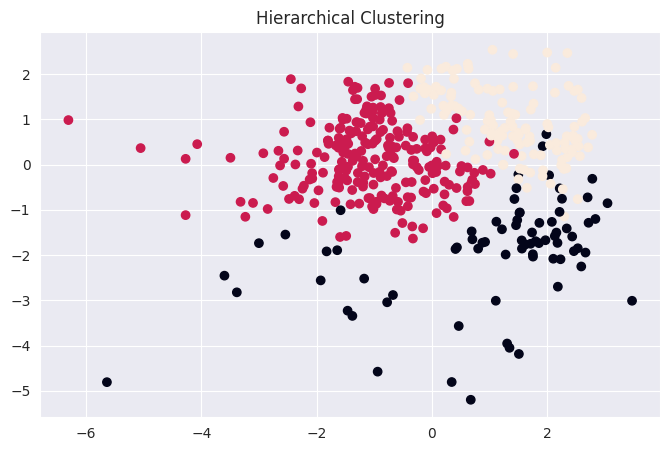

In [ ]:
hc = AgglomerativeClustering(n_clusters=3)
hc_labels = hc.fit_predict(scaled_data)

# Visualize
plt.figure(figsize=(8,5))
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=hc_labels)
plt.title("Hierarchical Clustering")
plt.show()

# 7. DBSCAN Clustering

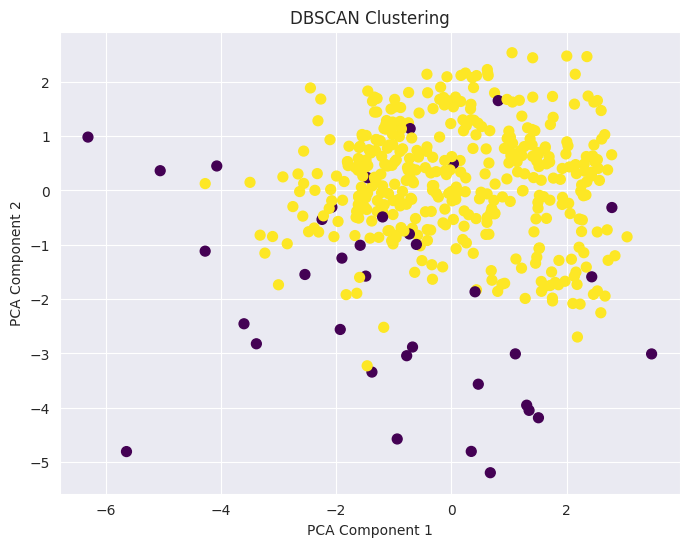

In [ ]:
dbscan = DBSCAN(eps=1.5, min_samples=5)
dbscan_labels = dbscan.fit_predict(scaled_data)

plt.figure(figsize=(8,6))

plt.scatter(pca_data[:, 0], pca_data[:, 1],
            c=dbscan_labels, cmap='viridis', s=50)

plt.title("DBSCAN Clustering")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.show()

# 8. Model Comparison and Conclusion

* K-Means produced well-defined clusters and was effective in segmenting
customers, but it required specifying the number of clusters in advance

* Hierarchical clustering provided a clear visual representation of cluster structure through the dendrogram and produced similar groupings to K-Means

* DBSCAN was able to identify noise points, but its performance was sensitive to parameter selection and resulted in less clearly defined clusters